# Who gets asked, and what the answer is worth

Same depression questionnaire (PHQ-9), two sources: **NHANES 2017–2018** (real, a
CDC household survey) and **Synthea v4.0.0** (synthetic, generated locally). For each
source, three numbers:

1. what share of adults were given the questionnaire,
2. what share of *those given it* scored 10 or higher,
3. the product of the two — the share of all adults scoring 10 or higher.

Then one follow-up question that the survey can't answer but the synthetic EHR can:
**does a positive screen lead to anything?**

Deliberately not done here: no modelling, no significance tests, no survey weights
(NHANES has a complex sampling design; these are raw unweighted proportions, which
is the cheaper of the two honest options), no third data source.

**Neither dataset is in this repo.** `./setup.sh` from this directory downloads the
NHANES files and generates the Synthea population — see the README for what it needs.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

NHANES = Path("data/nhanes")
CSV = Path("data/synthea/csv")
FIG = Path("figures"); FIG.mkdir(exist_ok=True)

BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8a8880", "#fcfcfb"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 11,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2,
    "axes.edgecolor": "#dedcd6", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.major.size": 0, "ytick.major.size": 0,
    "grid.color": "#e8e6e0", "grid.linewidth": 0.8,
    "legend.frameon": False, "figure.dpi": 160,
})

REQUIRED = [NHANES / "DPQ_J.xpt", NHANES / "DEMO_J.xpt",
            CSV / "patients.csv", CSV / "observations.csv", CSV / "encounters.csv",
            CSV / "medications.csv", CSV / "conditions.csv"]
absent = [p for p in REQUIRED if not p.exists()]
if absent:
    raise FileNotFoundError(
        "Nothing to read yet. Missing:\n  " + "\n  ".join(map(str, absent))
        + "\n\nRun ./setup.sh from this directory first (it fetches NHANES and "
          "generates the Synthea population).")
print(f"all {len(REQUIRED)} input files present")

all 7 input files present


## NHANES

`DPQ_J.xpt` is the depression screener, `DEMO_J.xpt` the demographics file; both are
public downloads from `wwwn.cdc.gov`. The nine scored items are `DPQ010`–`DPQ090`
(`DPQ100` asks how difficult the symptoms made daily life and is not part of the score).
`7` is refused and `9` is don't know, so neither counts as a response.

Denominator: adults 18+ who came to the mobile examination centre (`RIDSTATR == 2`),
where the questionnaire is administered. The DPQ file turns out to contain exactly that
set — 5,533 people, no more and no less.

**One trap worth naming.** In the transport file a true zero ("not at all") is eight zero
bytes and a missing value is `0x2E` — the ASCII `.` that SAS uses for missing. They are
genuinely distinct on disk. But pandas' XPORT reader returns that true zero as
`2**-260` ≈ `5.4e-79` rather than `0.0`, while mapping the missing marker to `NaN`
correctly. So `df.DPQ010 == 0` silently matches nothing, and any validity test written as
`isin([0, 1, 2, 3])` throws away every genuine zero. Summing is unaffected — 5.4e-79 adds
nothing — so the score itself looks fine while the *denominator* quietly collapses to the
people who never answered "not at all" to anything, i.e. the most symptomatic. Rounding
first is the fix; it moves the fake zeros and nothing else.

In [2]:
ITEMS = [f"DPQ0{i}0" for i in range(1, 10)]

dpq = pd.read_sas(NHANES / "DPQ_J.xpt", format="xport")
demo = pd.read_sas(NHANES / "DEMO_J.xpt", format="xport")

# pandas' XPORT reader hands back a true 0 as 2**-260, not 0.0. Missing (0x2E on disk)
# does arrive as NaN, so rounding only touches the genuine zeros -- see the note above.
for c in ITEMS:
    dpq[c] = dpq[c].round(0)

nh = demo[["SEQN", "RIDSTATR", "RIDAGEYR"]].merge(dpq, on="SEQN", how="left")
nh = nh[(nh.RIDAGEYR >= 18) & (nh.RIDSTATR == 2)]

v = nh[ITEMS]
nh_administered = v.notna().all(axis=1) & v.isin([0, 1, 2, 3]).all(axis=1)
nh_score = v[nh_administered].sum(axis=1)
nh_positive = nh_score >= 10

nhanes = {
    "n_adults": len(nh),
    "n_administered": int(nh_administered.sum()),
    "administered": nh_administered.mean(),
    "positive_given_administered": nh_positive.mean(),
    "positive_population": nh_positive.sum() / len(nh),
}
nhanes

{'n_adults': 5533,
 'n_administered': 5068,
 'administered': np.float64(0.9159587926983553),
 'positive_given_administered': np.float64(0.09056827150749802),
 'positive_population': np.float64(0.08295680462678474)}

Who the 465 non-scoreable people are, and whether the choice matters:

In [3]:
missing = nh[ITEMS].isna()
refused = nh[ITEMS].isin([7, 9])

breakdown = {
    "all 9 items missing": int(missing.all(axis=1).sum()),
    "partially answered": int((missing.any(axis=1) & ~missing.all(axis=1)).sum()),
    "complete but >=1 refused/don't know": int((refused.any(axis=1) & ~missing.any(axis=1)).sum()),
    "all 9 scoreable": int(nh_administered.sum()),
}

# the headline numbers under three defensible definitions of "was administered"
score_all = nh[ITEMS].where(nh[ITEMS].isin([0, 1, 2, 3])).sum(axis=1)
positive_all = score_all >= 10
alternatives = {}
for name, mask in [("all 9 scoreable", nh_administered),
                   ("engaged at all", ~missing.all(axis=1)),
                   ("nothing missing, 7/9 read as 0", ~missing.any(axis=1))]:
    p = positive_all & mask
    alternatives[name] = {"administered": round(mask.mean(), 4),
                          "positive_given_administered": round(p.sum() / mask.sum(), 4),
                          "positive_population": round(p.sum() / len(nh), 4)}

breakdown, alternatives

({'all 9 items missing': 439,
  'partially answered': 4,
  "complete but >=1 refused/don't know": 22,
  'all 9 scoreable': 5068},
 {'all 9 scoreable': {'administered': np.float64(0.916),
   'positive_given_administered': np.float64(0.0906),
   'positive_population': np.float64(0.083)},
  'engaged at all': {'administered': np.float64(0.9207),
   'positive_given_administered': np.float64(0.0905),
   'positive_population': np.float64(0.0833)},
  'nothing missing, 7/9 read as 0': {'administered': np.float64(0.9199),
   'positive_given_administered': np.float64(0.0906),
   'positive_population': np.float64(0.0833)}})

## Synthea

Generated locally, not the published sample data — the sample is built by a different
release, and the point of the exercise is to read the module JSON and then check the
output of *that same build*:

```
./run_synthea -p 10000 -s 20260815 -cs 20260815 \
    --exporter.csv.export=true --exporter.fhir.export=false \
    --generate.thread_pool_size=1
```

That last flag is not optional if you want the same numbers back. Synthea defaults to one
thread per core, and a fixed `-s` does **not** pin the result: two runs of the command
above without it gave 11,533 and 11,548 patients, and moved the positive rate by about
0.8 points. Single-threaded, the output is byte-identical run to run, about six times
slower. `setup.sh` does this for you.

Two sources are not measured the same way. NHANES is one cross-section: each person is
asked once. Synthea is a longitudinal record: a patient can be screened at every wellness
visit for decades, so "ever screened" is not comparable to anything in NHANES. So we take
a **two-year window** — the same shape as one NHANES cycle — and, within it, each person's
most recent PHQ-9.

Denominator: adults alive through the window who had at least one wellness encounter in
it. That is the analog of NHANES's "showed up for the exam."

In [4]:
PHQ9, PHQ2 = "44261-6", "55758-7"          # LOINC total-score codes
DEPRESSION = {"370143000", "36923009", "832007"}   # SNOMED
ANTIDEPRESSANTS = ("fluoxetine|sertraline|duloxetine|citalopram|paroxetine"
                   "|venlafaxine|bupropion|mirtazapine|amitriptyline|trazodone")
W0, W1 = pd.Timestamp("2024-01-01", tz="UTC"), pd.Timestamp("2025-12-31", tz="UTC")

pat = pd.read_csv(CSV / "patients.csv", usecols=["Id", "BIRTHDATE", "DEATHDATE"])
pat["BIRTHDATE"] = pd.to_datetime(pat.BIRTHDATE, utc=True)
pat["DEATHDATE"] = pd.to_datetime(pat.DEATHDATE, utc=True)
pat["age"] = (W0 - pat.BIRTHDATE).dt.days / 365.25
cohort = pat[(pat.age >= 18) & (pat.DEATHDATE.isna() | (pat.DEATHDATE > W1))].copy()

# observations.csv is a couple hundred MB, so pull only the two codes we need
chunks = []
for ch in pd.read_csv(CSV / "observations.csv", usecols=["DATE", "PATIENT", "CODE", "VALUE"],
                      dtype={"CODE": str, "VALUE": str}, chunksize=1_000_000):
    chunks.append(ch[ch.CODE.isin([PHQ9, PHQ2])])
obs = pd.concat(chunks, ignore_index=True)
obs["DATE"] = pd.to_datetime(obs.DATE, format="ISO8601", utc=True)
obs["VALUE"] = pd.to_numeric(obs.VALUE, errors="coerce")
obs = obs[(obs.DATE >= W0) & (obs.DATE <= W1)]

seen = set()
for ch in pd.read_csv(CSV / "encounters.csv", usecols=["START", "PATIENT", "ENCOUNTERCLASS"],
                      chunksize=1_000_000):
    c = ch[ch.ENCOUNTERCLASS == "wellness"]
    d = pd.to_datetime(c.START, format="ISO8601", utc=True)
    seen |= set(c.PATIENT[(d >= W0) & (d <= W1)])
cohort = cohort[cohort.Id.isin(seen)].copy()

last = obs.sort_values("DATE").groupby(["PATIENT", "CODE"]).agg(score=("VALUE", "last"),
                                                                date=("DATE", "last"))
cohort["phq2"] = cohort.Id.map(last.xs(PHQ2, level="CODE").score)
cohort["phq9"] = cohort.Id.map(last.xs(PHQ9, level="CODE").score)
cohort["phq9_date"] = cohort.Id.map(last.xs(PHQ9, level="CODE").date)

sy_administered = cohort.phq9.notna()
sy_score = cohort.phq9[sy_administered]
sy_positive = sy_score >= 10

synthea = {
    "n_adults": len(cohort),
    "n_administered": int(sy_administered.sum()),
    "administered": sy_administered.mean(),
    "positive_given_administered": sy_positive.mean(),
    "positive_population": sy_positive.sum() / len(cohort),
}
synthea

{'n_adults': 6936,
 'n_administered': 809,
 'administered': np.float64(0.11663783160322953),
 'positive_given_administered': np.float64(0.6378244746600742),
 'positive_population': np.float64(0.07439446366782007)}

### Does a positive screen lead to anything?

NHANES can't answer this — it is a survey, it ends when the interview ends. Synthea emits
a full record, so we can ask what happens in the twelve months after a score of 10 or higher.

In [5]:
med = pd.read_csv(CSV / "medications.csv", usecols=["START", "PATIENT", "DESCRIPTION"])
ad = med[med.DESCRIPTION.str.contains(ANTIDEPRESSANTS, case=False, na=False)].copy()
ad["START"] = pd.to_datetime(ad.START, format="ISO8601", utc=True)

cond = pd.read_csv(CSV / "conditions.csv", usecols=["START", "PATIENT", "CODE"], dtype={"CODE": str})
dep = cond[cond.CODE.isin(DEPRESSION)].copy()
dep["START"] = pd.to_datetime(dep.START, utc=True)

screened = cohort[sy_administered].set_index("Id")[["phq9", "phq9_date"]]

def followed_within(events, months=12):
    j = screened.join(events.set_index("PATIENT"), how="left")
    days = (j.START - j.phq9_date).dt.days
    return j.assign(hit=(days >= 0) & (days <= months * 30.4)).groupby(level=0).hit.any()

screened["antidepressant_12mo"] = followed_within(ad)
screened["depression_dx_12mo"] = followed_within(dep)
high = screened.phq9 >= 10

cascade = [
    ("Adults at a wellness visit", len(cohort)),
    ("Given a PHQ-2", int(cohort.phq2.notna().sum())),
    ("Given a PHQ-9", int(sy_administered.sum())),
    ("Scored 10 or higher", int(sy_positive.sum())),
    ("→ depression dx ≤ 12 mo", int(screened.depression_dx_12mo[high].sum())),
    ("→ antidepressant ≤ 12 mo", int(screened.antidepressant_12mo[high].sum())),
]
cascade

[('Adults at a wellness visit', 6936),
 ('Given a PHQ-2', 6251),
 ('Given a PHQ-9', 809),
 ('Scored 10 or higher', 516),
 ('→ depression dx ≤ 12 mo', 0),
 ('→ antidepressant ≤ 12 mo', 0)]

In [6]:
# every antidepressant in the whole population, and what it was prescribed for
reasons = pd.read_csv(CSV / "medications.csv", usecols=["DESCRIPTION", "REASONDESCRIPTION"])
reasons = reasons[reasons.DESCRIPTION.str.contains(ANTIDEPRESSANTS, case=False, na=False)]
reasons.value_counts(dropna=False)

DESCRIPTION                                    REASONDESCRIPTION                          
Sertraline 100 MG Oral Tablet                  Posttraumatic stress disorder (disorder)       57
FLUoxetine 20 MG Oral Capsule                  Major depression  single episode (disorder)    40
duloxetine 20 MG Delayed Release Oral Capsule  Primary fibromyalgia syndrome (disorder)       31
Name: count, dtype: int64

## Figure 1 — the three rates

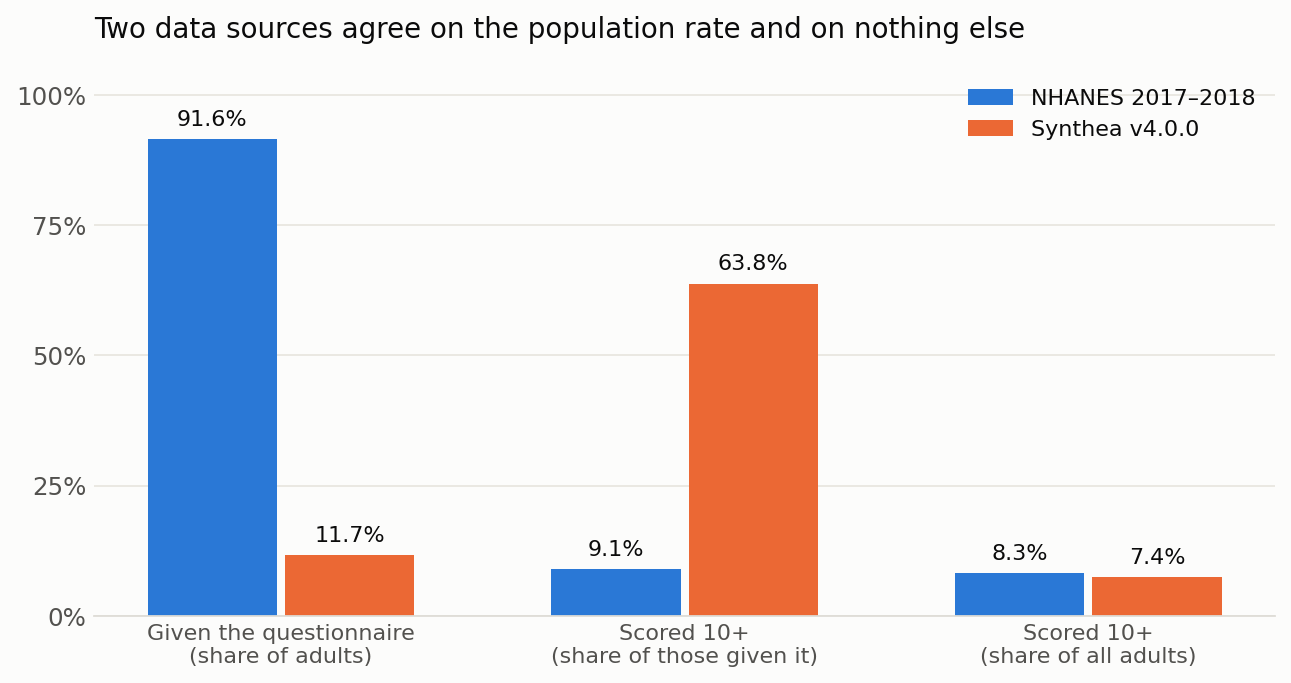

In [7]:
def pct(x):
    return f"{100 * x:.1f}%"

labels = ["Given the questionnaire\n(share of adults)",
          "Scored 10+\n(share of those given it)",
          "Scored 10+\n(share of all adults)"]
nv = [nhanes["administered"], nhanes["positive_given_administered"], nhanes["positive_population"]]
sv = [synthea["administered"], synthea["positive_given_administered"], synthea["positive_population"]]

fig, ax = plt.subplots(figsize=(8.2, 4.4))
x, w = np.arange(3), 0.32
b1 = ax.bar(x - w / 2 - 0.01, nv, w, color=BLUE, label="NHANES 2017–2018")
b2 = ax.bar(x + w / 2 + 0.01, sv, w, color=ORANGE, label="Synthea v4.0.0")
for bars, vals in ((b1, nv), (b2, sv)):
    for b, val in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.018, pct(val),
                ha="center", va="bottom", fontsize=10, color=INK)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 1.05); ax.set_yticks(np.arange(0, 1.01, 0.25))
ax.set_yticklabels([f"{int(t * 100)}%" for t in np.arange(0, 1.01, 0.25)])
ax.yaxis.grid(True); ax.set_axisbelow(True); ax.spines["left"].set_visible(False)
ax.legend(loc="upper right", fontsize=10)
ax.set_title("Two data sources agree on the population rate and on nothing else",
             loc="left", fontsize=12.5, pad=14, color=INK)
fig.tight_layout(); fig.savefig(FIG / "01-three-rates.png")

## Figure 2 — score distribution among those screened

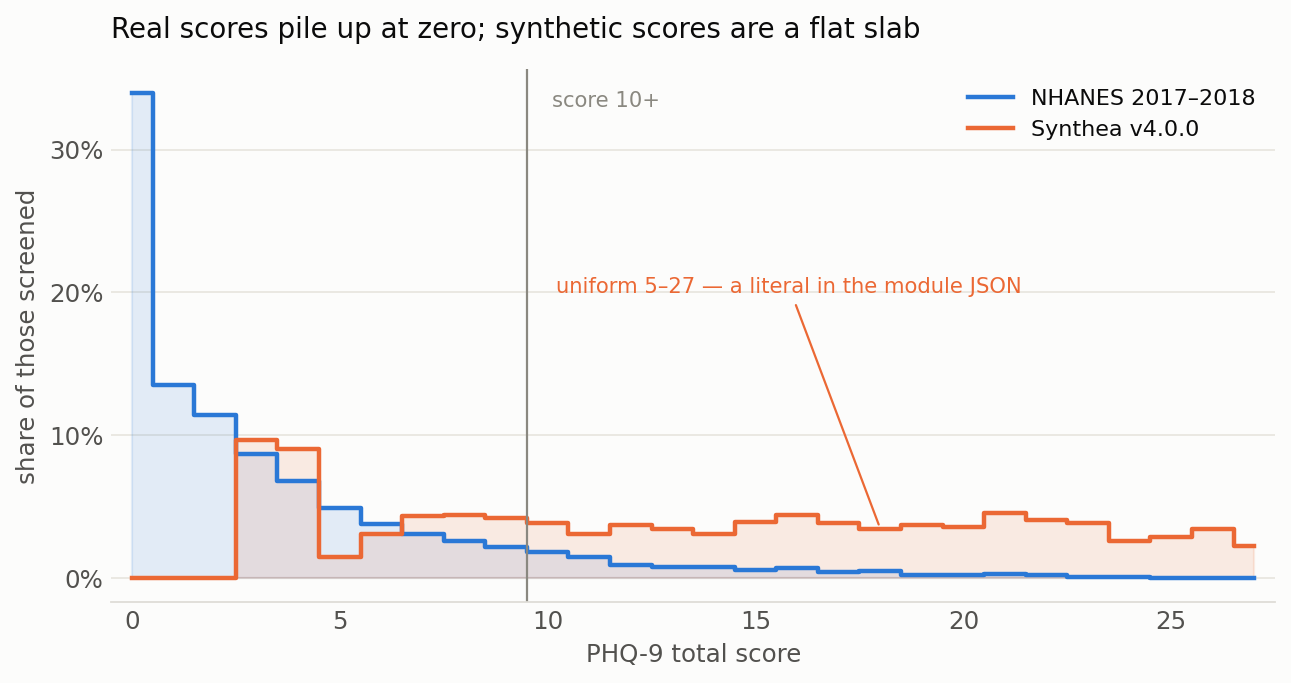

In [8]:
def share(scores):
    c = scores.value_counts().reindex(range(0, 28), fill_value=0).sort_index()
    return c / c.sum()

nh_share, sy_share = share(nh_score), share(sy_score)
xs = np.arange(0, 28)

fig, ax = plt.subplots(figsize=(8.2, 4.4))
ax.fill_between(xs, nh_share, step="mid", color=BLUE, alpha=0.12)
ax.fill_between(xs, sy_share, step="mid", color=ORANGE, alpha=0.12)
ax.step(xs, nh_share, where="mid", color=BLUE, linewidth=2, label="NHANES 2017–2018")
ax.step(xs, sy_share, where="mid", color=ORANGE, linewidth=2, label="Synthea v4.0.0")
ax.axvline(9.5, color=MUTED, linewidth=1)
ax.text(10.1, 0.33, "score 10+", fontsize=9.5, color=MUTED)
ax.annotate("uniform 5–27 — a literal in the module JSON",
            xy=(18, sy_share[18]), xytext=(10.2, 0.20), fontsize=9.5, color=ORANGE,
            arrowprops=dict(arrowstyle="-", color=ORANGE, linewidth=1))
ax.set_xlabel("PHQ-9 total score"); ax.set_ylabel("share of those screened")
ax.set_xlim(-0.5, 27.5)
ax.set_yticks(np.arange(0, 0.36, 0.1))
ax.set_yticklabels([f"{int(t * 100)}%" for t in np.arange(0, 0.36, 0.1)])
ax.yaxis.grid(True); ax.set_axisbelow(True); ax.spines["left"].set_visible(False)
ax.legend(loc="upper right", fontsize=10)
ax.set_title("Real scores pile up at zero; synthetic scores are a flat slab",
             loc="left", fontsize=12.5, pad=14, color=INK)
fig.tight_layout(); fig.savefig(FIG / "02-score-distribution.png")

## Figure 3 — what a positive screen leads to

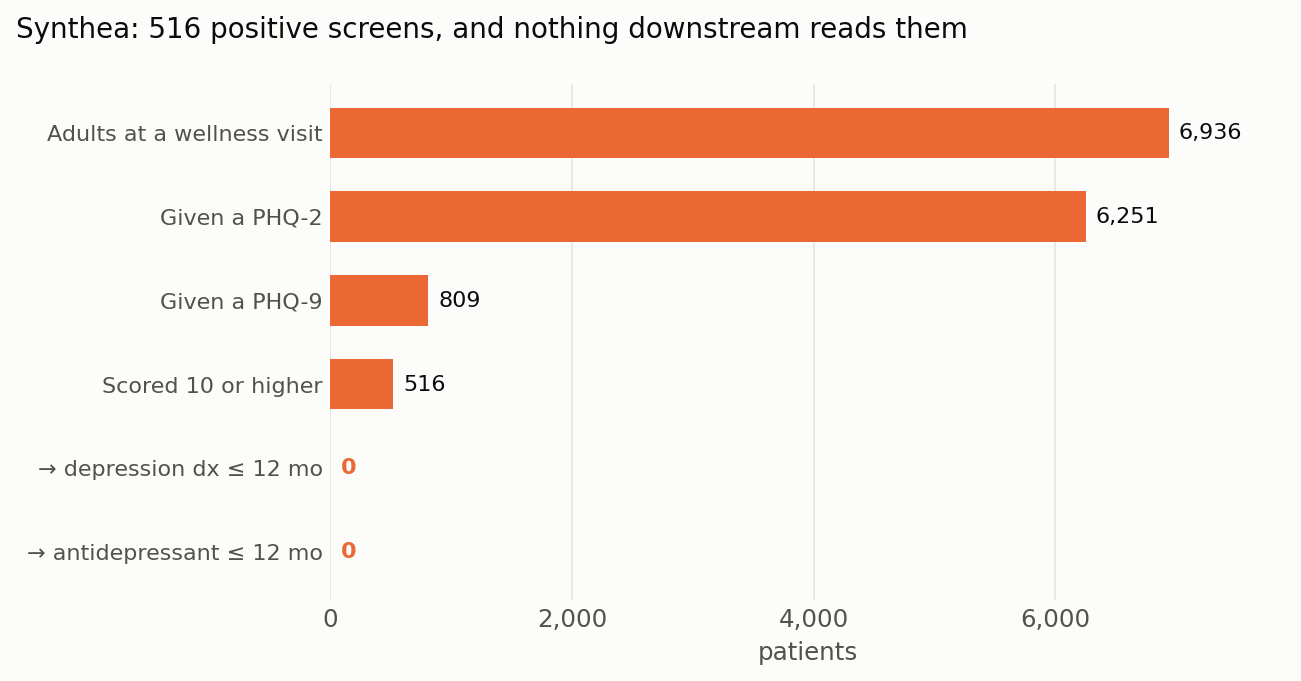

In [9]:
names = [c[0] for c in cascade][::-1]
vals = [c[1] for c in cascade][::-1]

fig, ax = plt.subplots(figsize=(8.2, 4.4))
bars = ax.barh(names, vals, height=0.6, color=ORANGE)
for b, val in zip(bars, vals):
    ax.text(b.get_width() + max(vals) * 0.012, b.get_y() + b.get_height() / 2, f"{val:,}",
            va="center", fontsize=10, color=INK if val else ORANGE,
            fontweight="normal" if val else "bold")
ax.set_xlim(0, max(vals) * 1.14)
ax.set_xticks(np.arange(0, max(vals) + 1, 2000))
ax.set_xticklabels([f"{int(t):,}" for t in np.arange(0, max(vals) + 1, 2000)])
ax.xaxis.grid(True); ax.set_axisbelow(True)
ax.spines["left"].set_visible(False); ax.spines["bottom"].set_visible(False)
ax.tick_params(axis="y", labelsize=10)
ax.set_xlabel("patients")
fig.tight_layout(rect=(0, 0, 1, 0.90))
fig.text(0.012, 0.94,
         f"Synthea: {int(sy_positive.sum())} positive screens, and nothing downstream reads them",
         fontsize=12.5, color=INK, ha="left", va="center")
fig.savefig(FIG / "03-what-follows.png")

## What the module actually says

The three figures are consequences of about forty lines of
`src/main/resources/modules/encounter/depression_screening.json`, which is worth reading
directly rather than inferring from the output:

- It is called from `wellness_encounters.json` with probability **0.8** per wellness
  encounter. It is routine, not indication-triggered.
- Eligibility is an **exclusion** list: age < 12, pregnant, an active *Major depressive
  disorder* (SNOMED `370143000`), or an active anti-suicide psychotherapy careplan
  (SNOMED `183401008`). Patients already known to be depressed are screened out.
- Adults get a PHQ-2 first, with a hard-coded **6%** positive rate; only `phq2_score >= 3`
  proceeds to the PHQ-9.
- Of adults reaching the PHQ-9, **80%** take the `Positive` branch, which sets
  `phqa_score` to `UNIFORM(5, 27)` rounded. The other 20% get `UNIFORM(3, 4)`.
- Nothing outside this module ever reads `phqa_score` or `phq2_score`. Grep the whole
  module tree and the only hits are inside the file itself.

That last point is what figure 3 shows from the other end. Antidepressants do exist in
the output, but they are prescribed for PTSD, veteran MDD, and fibromyalgia — never in
response to a score.